In [1]:
import h5py
from scipy import signal
from scipy.signal import welch, csd
import matplotlib
import matplotlib.pyplot as plt
import os
from os import listdir
import numpy as np
from scipy import fft
from scipy.signal import find_peaks
import lmfit
from datetime import datetime
from datetime import timedelta
#file by file data analysise

## Transient filter search for MAGE data stream. First test designed for MAGE0 Data

#load data file
folder = r"C:\Users\21958742\MAGE/"
exp_name = "MAGE3"
run_name = "run2"
identifier = 'run2-'

files = listdir(folder + '/' + exp_name + '/' + run_name)
Nfiles = len(files)

#meta data from first file
f = h5py.File(folder + '/' + exp_name + '/' + run_name + '/' + files[0], 'r')
f1 = h5py.File(folder + '/' + exp_name + '/' + run_name + '/' + files[1], 'r')

#load calibration data
fsquid = open(folder + '/' + exp_name + '/calibration/SQUID gain models.txt')
fresistance = open(folder + '/' + exp_name + '/calibration/Rs.txt')
squid_model = np.genfromtxt(fsquid, skip_header=1, delimiter=',')
resistances = np.genfromtxt(fresistance, delimiter=',')

Ninputs = len(f.keys())
Nchannels = len(f['AI 0'].keys())//2
Nsample = len(f1['AI 0/CH 1-I/Data'][:])
Fs = f['AI 0'].attrs['Fs']
dt = 1/Fs
data_array = np.zeros((Ninputs, Nchannels, 2, Nsample))
t_start_string = str(f['AI 0'].attrs['date/time string'])
t_start = datetime.strptime(t_start_string, 'UTC %d-%m-%y %H:%M:%S.%f ')

kb = 1.380649e-23
event_catalogue={}
#create output folder to store analysis results
output_path = folder + '/' + exp_name + '/Analysis/' + run_name + '-1 sigma'
if os.path.exists(output_path) == False:
    os.makedirs(output_path)

#filter function
def optimal_filter(data, template, Fs, NFFT):
    fft = np.fft.fft(data) # fourier transformed data
    zero_pad = np.zeros(data.size - template.size) # zero pad template to match data size
    template_pad = np.append(template, zero_pad)
    fft_template = np.fft.fft(template_pad) # fourier transformed padded template
    power_dat, freq_PSD = plt.psd(data, Fs=Fs, NFFT = NFFT, visible = True)
    freq_dat = np.fft.fftfreq(data.size)*Fs #fourier frequencies corresponding to data partition
    power_spec = np.interp(freq_dat, freq_PSD, power_dat)
    
    df = np.abs(freq_dat[1] - freq_dat[2])
    opt_filter = fft * fft_template.conjugate() / power_spec #optimal filter
    dat_filt = 2*np.fft.ifft(opt_filter) #revert to time domain for filter output
    
    sigmasq = 4*(fft_template * fft_template.conjugate() / power_spec).sum() * df 
    sigma = np.sqrt(np.abs(sigmasq))
    SNR = abs(dat_filt) / (sigma)
    return SNR
def fit_spectrum(Sx_trim,Sy_trim,fn_trim, plotting=True):
    
    pars = peak_model.guess(Sx_trim, x=fn_trim)
    pars += noise_model.guess(Sx_trim, x=fn_trim)
    pars2 = peak_model.guess(Sx_trim, x=fn_trim)
    pars2 += noise_model.guess(Sx_trim, x=fn_trim)
    model = peak_model + noise_model

    out = model.fit(Sx_trim, pars, x=fn_trim)
    out2 = model.fit(Sy_trim, pars2, x=fn_trim)
    Gamma1, Gamma2 = out.params["sigma"].value, out2.params["sigma"].value
    fcenter1, fcenter2 = out.params["center"].value, out2.params["center"].value
    f_demod = f['AI ' + str(AI)].attrs['Demod freqs AI ' + str(AI)][channel] # demodulation frequency

    Q1, Q2 = (fcenter1+f_demod)/(2*Gamma1), (fcenter2+f_demod)/(2*Gamma2)
    if out.params["sigma"].stderr == None:
        error1 = 0.99
    else:
        error1 =  out.params["sigma"].stderr/out.params["sigma"].value
    if out2.params["sigma"].stderr == None:
        error2 = 0.99
    else:
        error2 =  out2.params["sigma"].stderr/out2.params["sigma"].value
    if Gamma1 > Gamma_max or Gamma2 > Gamma_max or error1 > error_max or error2 > error_max: #Ignore bad fits
        print("Input AI " + str(AI) + ", Channel " + str(channel+1) + ":WARNING: Bad mode detected, channel will be ignored")
    if plotting==True:
        fig = plt.figure("IMPA DOWNLOAD")
        plt.axis('tight')
        ax = fig.add_subplot(111)
        ax.plot(fn_trim, Sx_trim, 'o', markersize=0.2)
        ax.set_title("Input AI " + str(AI) + ", Channel " + str(channel+1))
        #plt.plot(fn_n, out.init_fit, '--', label='initial fit')
        ax.plot(fn_trim, out.best_fit, '-', label='best fit I')
        ax.plot(fn_trim, out2.best_fit, '-', label='best fit Q')
        ax.set_yscale('log')
        #ax.set_xscale('log')
        ax.legend()
    return Q1,Q2,Gamma1,Gamma2,fcenter1,fcenter2

In [68]:
file = 105
channel = 3
AI = 0

from lmfit.models import LorentzianModel, LinearModel

In [69]:
f = h5py.File(folder + '/' + exp_name + '/' + run_name + '/' + identifier + str(file) + '.hdf5', 'r')
dataI = f['AI ' + str(AI) + '/CH ' + str(channel+1) + '-I/Data'][:]*9.86e-10
dataQ = f['AI ' + str(AI) + '/CH ' + str(channel+1) + '-Q/Data'][:]*9.86e-10

#Determine single sided power spectrum for each stream
NFFT = 2**12 # for NFFT < Nsample power spectrum will be averaged

fn, SdataI = welch(dataI, fs=Fs, nperseg = 2*NFFT-1, scaling = 'density')
fn, SdataQ = welch(dataQ, fs=Fs, nperseg = 2*NFFT-1, scaling = 'density')



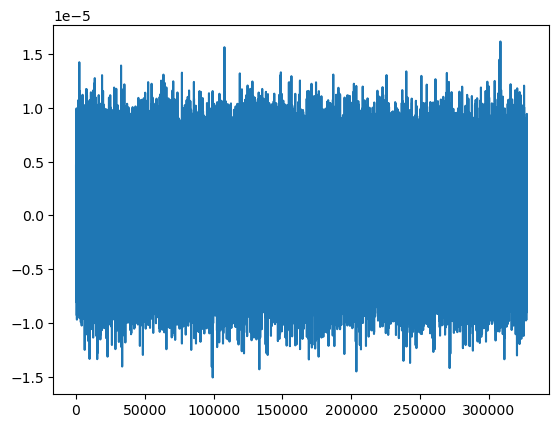

In [70]:
plt.plot(dataQ)

In [71]:
Gamma_max = 20.0 #Maximum accepted linewidth in Hz
error_max = 0.2 #Maximum accepted standard fit error in Hz

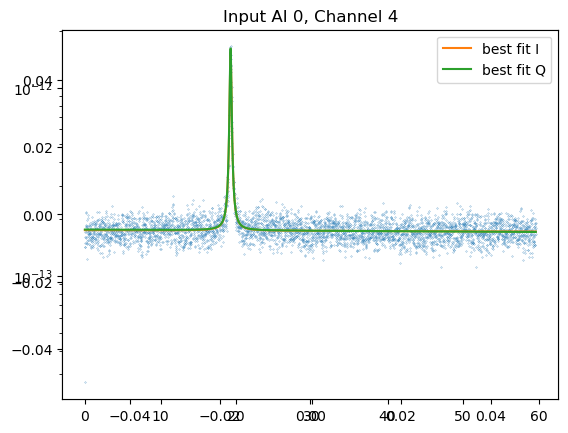

In [72]:
peak_model = LorentzianModel()
noise_model = LinearModel()

Sx_trim = SdataI
Sy_trim = SdataQ
fn_trim = fn

Q1,Q2,Gamma1,Gamma2,fc1,fc2 = fit_spectrum(Sx_trim, Sy_trim, fn_trim)

In [73]:
Nfilter=NFFT
tn = np.linspace(0,Nsample*dt,Nsample)
t_sig = dt*np.linspace(0, Nfilter, Nfilter)
Φ = 3*np.pi/4

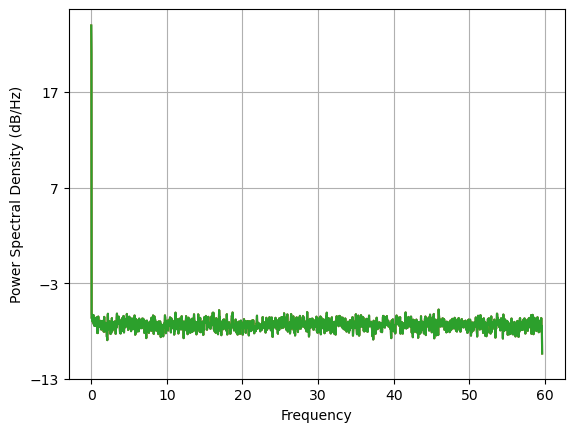

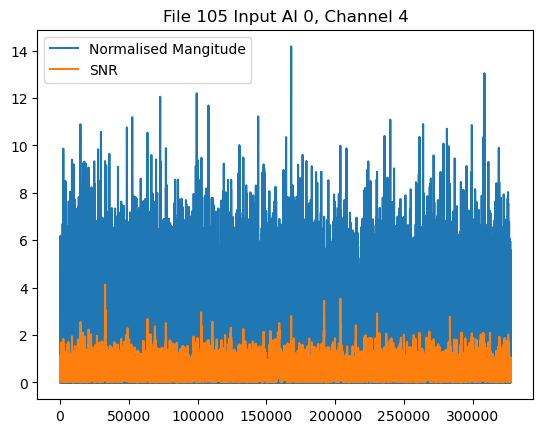

In [74]:
f_demod = f['AI ' + str(AI)].attrs['Demod freqs AI ' + str(AI)][channel] # demodulation frequency
tau1, tau2 = np.array([Q1,Q2])/(np.pi*f_demod)
fpeak_sig = fc1

G = squid_model[AI][0]/np.sqrt(1+(f_demod/squid_model[AI][1])**2) #squid gain
VtoT = (1/G)**2*resistances[channel][AI]*tau1/kb/4

Idat, Qdat = dataI, dataQ # Phase and quadrature data to be filtered

Rdat = (Idat**2+Qdat**2)*VtoT
Tn=Rdat
template = np.exp(-t_sig/(tau1)) # template construction
data = Rdat

SNR = optimal_filter(data, template, Fs, NFFT)
threshold = 1.0
peaks = find_peaks(SNR, height = threshold, distance = int(tau1*Fs), width = [100, 5e6], rel_height=1.0)

## data quality cuts
if len(peaks[0])>0:
    diverge_template1 = np.exp(-t_sig/(tau1/10.0))
    diverge_template2 = np.exp(-t_sig/(tau1/100.0))
    transient_SNR1 = optimal_filter(data, diverge_template1, Fs, NFFT)           
    transient_SNR2 = optimal_filter(data, diverge_template2, Fs, NFFT)
fig = plt.figure("Filtered Output")
ax = fig.add_subplot(111)
ax.set_title("File " + str(file) + " Input AI " + str(AI) + ", Channel " + str(channel+1))
ax.plot(Tn/np.mean(Tn), label = 'Normalised Mangitude')
ax.plot(SNR, label = 'SNR')
ax.legend()
#ax.plot(peaks[0]*dt,peaks[1]['peak_heights'], linestyle = ' ', marker = 'x', color = 'black')

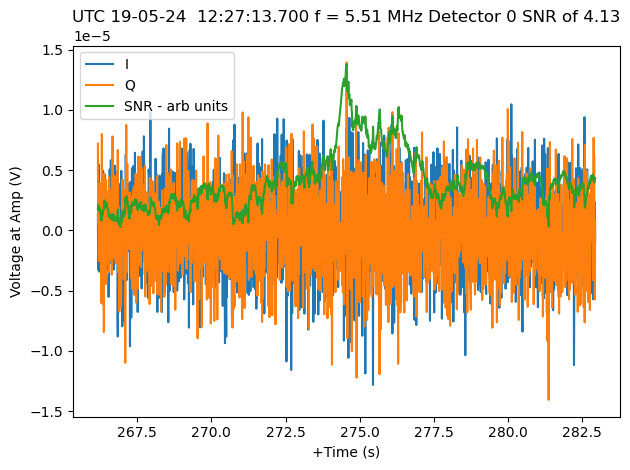

In [75]:
date = f['AI 0'].attrs['date/time string'][:]

nn = 32730
span = 1000
plt.plot(tn[nn-span:nn+span], Idat[nn-span:nn+span], label= 'I')
plt.plot(tn[nn-span:nn+span], Qdat[nn-span:nn+span], label = 'Q')
plt.plot(tn[nn-span:nn+span], SNR[nn-span:nn+span]/3e5, label = 'SNR - arb units')
plt.legend(loc=0)
plt.title(date + 'f = %1.2f MHz Detector %1i SNR of %1.2f' % (f_demod/1e6, AI, np.max(SNR)))
plt.xlabel('+Time (s)')
plt.ylabel('Voltage at Amp (V)')
plt.tight_layout()
pp = r'C:\Users\21958742\MAGE\MAGE3\Analysis\\' + date[:12] + '-%1.2f-SNR.pdf' % (np.max(SNR))
#plt.savefig(pp, format='pdf', dpi=600)

Input AI 0, Channel 8:WARNING: Bad mode detected, channel will be ignored


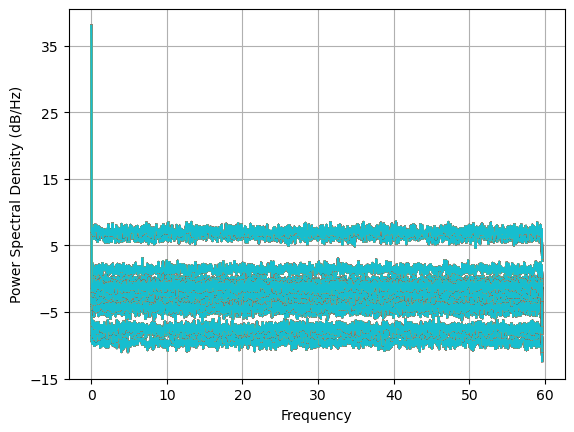

In [77]:
#nn = 172525
AI = 0
Ntemplates = 50
Span = 2000
SNR_arr = np.zeros((16,Ntemplates, Span))
for channel in range(16):
    dataI = f['AI ' + str(AI) + '/CH ' + str(channel+1) + '-I/Data'][:]*9.86e-10
    dataQ = f['AI ' + str(AI) + '/CH ' + str(channel+1) + '-Q/Data'][:]*9.86e-10
    NFFT = 2**12 # for NFFT < Nsample power spectrum will be averaged
    fn, SdataI = welch(dataI, fs=Fs, nperseg = 2*NFFT-1, scaling = 'density')
    fn, SdataQ = welch(dataQ, fs=Fs, nperseg = 2*NFFT-1, scaling = 'density')
    Q1,Q2, Gamma1, Gamma2,fc1,fc2 = fit_spectrum(SdataI, SdataQ, fn, plotting=False)
    
    f_demod = f['AI ' + str(AI)].attrs['Demod freqs AI ' + str(AI)][channel] # demodulation frequency
    tau1, tau2 = np.array([Q1,Q2])/(np.pi*f_demod)
    fpeak_sig = fc1

    G = squid_model[AI][0]/np.sqrt(1+(f_demod/squid_model[AI][1])**2) #squid gain
    VtoT = (1/G)**2*resistances[channel][AI]*tau1/kb/4
    data = (dataI**2+dataQ**2)*VtoT
    tau_vec = tau1*np.logspace(-3,3,Ntemplates)
    for i in range(Ntemplates):
        template = np.exp(-t_sig/(tau_vec[i]))
        SNR = optimal_filter(data, template, Fs, NFFT)
        SNR_arr[channel,i,:] = SNR[nn-Span//2:nn+Span//2]


(0.001, 1000)

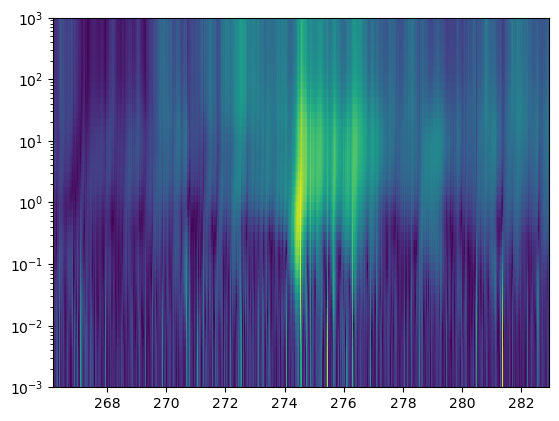

In [123]:
XX, YY = np.meshgrid(tn[nn-Span//2:nn+Span//2], tau_vec/tau1)
ZZ = SNR_arr[3,:,:]
fig, ax = plt.subplots(1)
ax.pcolormesh(XX,YY, ZZ, cmap='viridis')
ax.set_yscale('log')
ax.set_ylim(0.001,1000)

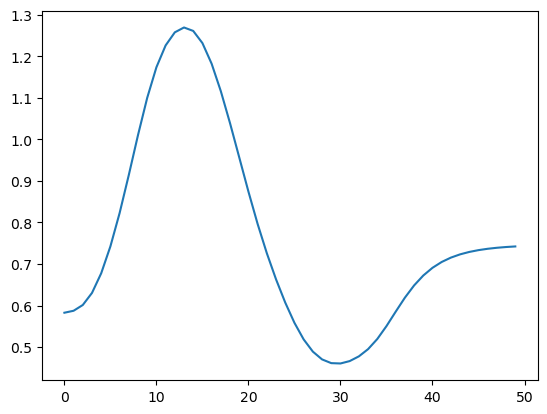

In [143]:
plt.plot(SNR_arr[0,:,Span//2-1])

In [92]:
f['AI 0'].attrs['Demod freqs AI 0']

array([ 4993020.,  5080765.,  5088518.,  5505659.,  5577295.,  8392114.,
        9152185.,  9411002.,  9453752.,  5603980.,  8297582.,  8400409.,
        9225457.,  9247221.,  9527616., 15734328.])

1

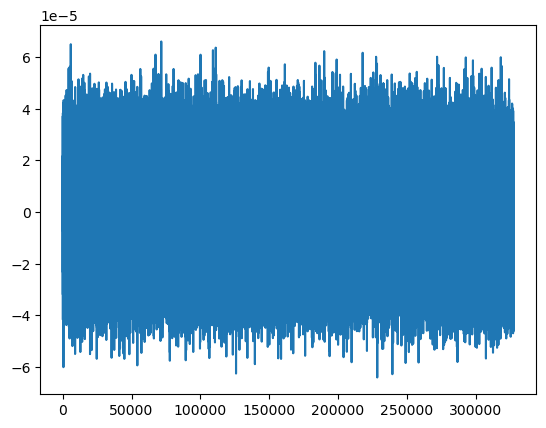

In [1052]:
plt.plot(dataQ)
channel

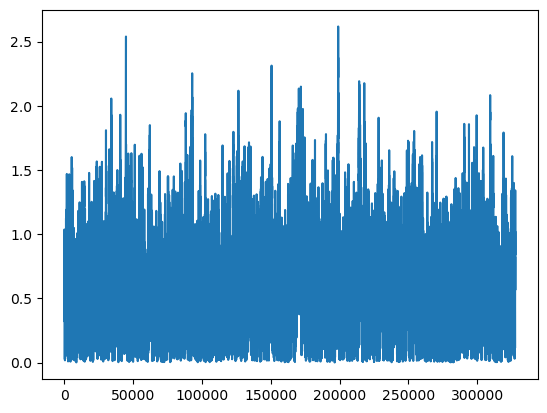

In [1053]:

plt.plot(SNR)